## Day 4 — t-SNE & Anomaly Detection

In [63]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest

In [43]:
df = pd.read_csv('/content/car data.csv')

In [44]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [45]:
numeric_cols = ['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner']

X_numeric = df[numeric_cols]
X_numeric.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
0,2014,3.35,5.59,27000,0
1,2013,4.75,9.54,43000,0
2,2017,7.25,9.85,6900,0
3,2011,2.85,4.15,5200,0
4,2014,4.60,6.87,42450,0


In [46]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_cols)
X_scaled_df.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
0,0.128897,-0.258416,-0.236215,-0.256224,-0.174501
1,-0.217514,0.017481,0.221505,0.155911,-0.174501
2,1.168129,0.510154,0.257427,-0.773969,-0.174501
3,-0.910335,-0.356950,-0.403079,-0.817758,-0.174501
4,0.128897,-0.012079,-0.087890,0.141743,-0.174501


In [47]:
print("Mean per column:\n", X_scaled_df.mean().round(2))
print("\nStd per column:\n", X_scaled_df.std().round(2))

Mean per column:
 Year            -0.0
Selling_Price   -0.0
Present_Price   -0.0
Kms_Driven       0.0
Owner            0.0
dtype: float64

Std per column:
 Year             1.0
Selling_Price    1.0
Present_Price    1.0
Kms_Driven       1.0
Owner            1.0
dtype: float64


#### Why Scaling Matters Here

`Present_Price` and `Selling_Price` are measured in lakhs (large
magnitude), while `Owner` ranges only 0-3 and `Year` is a 4-digit number
with a narrow range. Without scaling, distance-based methods (K-Means,
PCA) would be dominated entirely by whichever column happens to have the
largest raw magnitude (`Kms_Driven` here), regardless of its actual
importance. `StandardScaler` transforms every column to have mean 0 and
standard deviation 1, giving each feature equal weight before applying
any unsupervised technique.

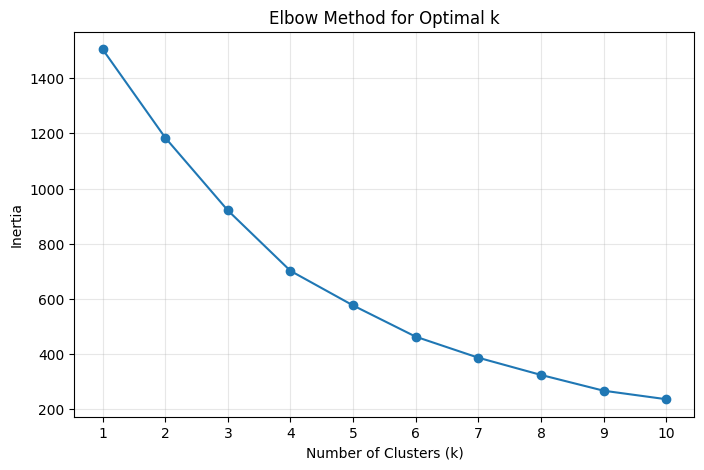

In [48]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.grid(alpha=0.3)
plt.show()

#### Reading the Elbow

Inertia drops sharply from k=1 to k=4 (1508 → ~700), then the rate of
decrease flattens noticeably from k=4 onward, with only modest
incremental improvement through k=10.

The elbow appears around **k = 4** — this is where the curve transitions
from steep decline to a much gentler slope. Adding clusters beyond 4
continues to reduce inertia, but each additional cluster buys
increasingly little, suggesting the data has roughly 4 natural groupings
rather than more granular structure.

**Chosen value: k = 4**

In [49]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

df['Cluster'] = clusters
df.groupby('Cluster')[numeric_cols].mean()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
Cluster,,,,,
0,2014.827907,4.147209,5.872400,26588.167442,0.000000
1,2011.454545,2.018182,5.171818,41304.000000,1.181818
2,2009.338983,2.623898,7.689898,71201.728814,0.000000
3,2014.812500,20.899375,32.688125,46837.937500,0.000000


With k=4 selected, each car is now assigned to one of 4 clusters based on
its scaled numeric features. The next step is to examine what
distinguishes each cluster (e.g. newer/cheaper vs. older/expensive cars)
and visualize the result, typically after reducing to 2D with PCA for
plotting.

In [50]:
candidate_ks = [3, 4]

for k in candidate_ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}: Silhouette Score = {score:.4f}")

k=3: Silhouette Score = 0.4379
k=4: Silhouette Score = 0.4122


#### Silhouette Score Results

| k | Silhouette Score |
|---|---|
| 3 | 0.4379 |
| 4 | 0.4122 |

**Chosen k = 3**

k=3 achieves a higher silhouette score (0.4379 vs. 0.4122), indicating
tighter, better-separated clusters despite the elbow plot's slightly
sharper bend at k=4. This is a common and expected discrepancy — the
elbow method is a visual heuristic based on inertia alone, while
silhouette score directly measures cluster quality (cohesion and
separation), making it the more reliable criterion when the two disagree.

In [51]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

df['Cluster'] = clusters

In [52]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance captured:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.38297707 0.32514126]
Total variance captured: 0.7081183339884483


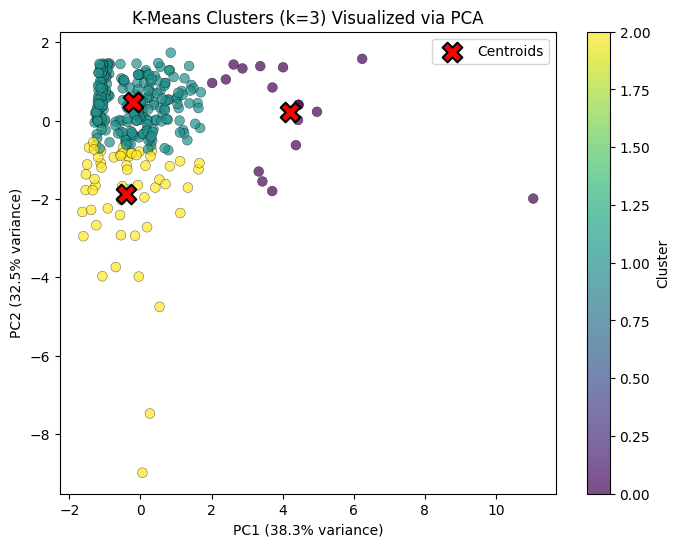

In [53]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis',
                       alpha=0.7, s=50, edgecolor='k', linewidth=0.3)

# Drawing the cluster centers (after converting them to the same PCA space)
centers_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', marker='X',
            s=200, edgecolor='black', linewidth=1.5, label='Centroids')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('K-Means Clusters (k=3) Visualized via PCA')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.show()

#### Visualizing the Clusters in 2D

The PCA projection shows one large, dense cluster (teal, Cluster 1 —
budget/low-mileage cars) tightly packed near the origin, while Clusters 0
(purple, premium) and 2 (yellow, older/high-mileage) are more spread out
and overlap more with each other along PC1.

Several notable outliers are visible — particularly one purple point far
right (~PC1=11), likely an unusually expensive car, and several yellow
points with very negative PC2 (down to ~−9), likely cars with extreme
mileage or age relative to the rest of the data. These outliers pull
their respective cluster centroids away from their main point mass,
visible in how the yellow centroid sits noticeably above the bulk of
yellow points.

The visible overlap between clusters (especially 0 and 2) is consistent
with the moderate silhouette score (0.44) — clusters are reasonably
distinct but not perfectly separated, and only 71% of total variance is
captured in this 2D view, so some separation exists in dimensions not
shown here.

In [54]:
df.groupby('Cluster')[numeric_cols].mean().round(2)

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
Cluster,,,,,
0,2014.88,20.54,31.64,45435.71,0.00
1,2014.68,4.04,5.85,27600.88,0.00
2,2009.16,2.43,7.53,70877.64,0.21


#### Interpreting the Clusters

| Cluster | Year | Price | Present Price | Kms | Owner | Profile |
|---|---|---|---|---|---|---|
| 0 | 2014.9 | 20.54 | 31.64 | 45,436 | 0.00 | Premium cars |
| 1 | 2014.7 | 4.04 | 5.85 | 27,601 | 0.00 | Budget, low-mileage |
| 2 | 2009.2 | 2.43 | 7.53 | 70,878 | 0.21 | Older, high-mileage |

Clustering separates cars along two independent factors: **price tier**
(Cluster 0's premium pricing vs. Cluster 1's budget range, despite
similar age) and **age/wear** (Cluster 2's older, high-mileage,
multi-owner profile). This matches the PCA result, where two components
of comparable variance (38% / 33%) reflect these distinct dimensions
rather than one dominant factor.

In [55]:
df.head(10)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Cluster
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,1
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,1
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,1
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,1
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,1
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0,1
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0,1
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0,1
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0,1
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0,1


In [56]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# Select numerical features
X = df[['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner']]

# Scale the data
X_scaled = StandardScaler().fit_transform(X)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# Add cluster labels
df['DBSCAN_Cluster'] = labels

# Number of clusters (excluding noise = -1)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

# Number of noise points
n_noise = list(labels).count(-1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

Number of clusters: 2
Number of noise points: 35


#### DBSCAN Clustering Results

DBSCAN was applied to the Day 1 dataset to identify groups based on data density.

- **Number of clusters:** 2
- **Number of noise points:** 35

The model identified **2 distinct clusters** and classified **35 data points as noise**, meaning they did not belong to any sufficiently dense cluster.

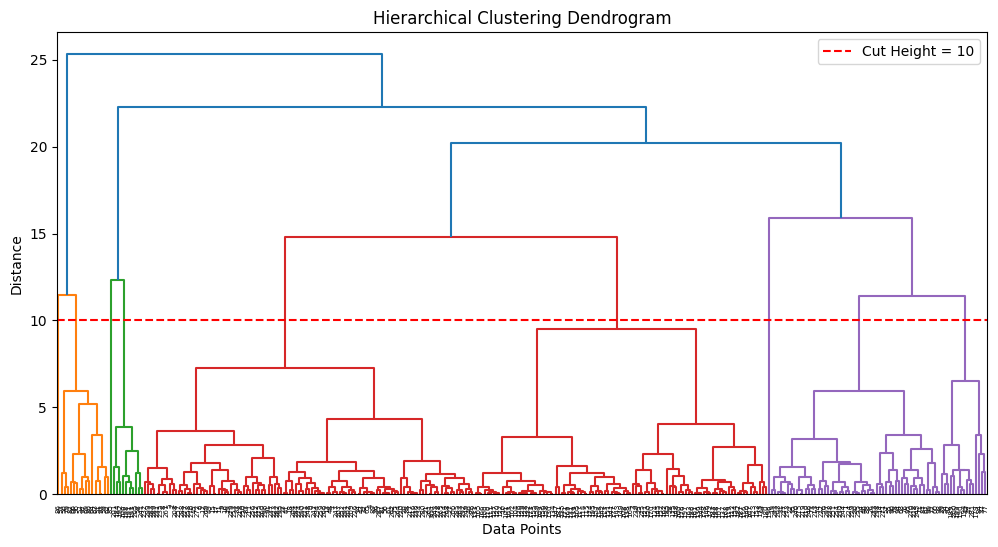

In [57]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Select numerical features
X = df[['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner']]

# Scale the data
X_scaled = StandardScaler().fit_transform(X)

# Hierarchical clustering
Z = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))

dendrogram(Z)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.axhline(y=10, color='red', linestyle='--', label='Cut Height = 10')
plt.legend()
plt.show()

In [58]:
from scipy.cluster.hierarchy import fcluster
cut_height = 10
clusters = fcluster(Z, t=cut_height, criterion='distance')

df['Hierarchical_Cluster'] = clusters

n_clusters = df['Hierarchical_Cluster'].nunique()

print("Cut height:", cut_height)
print("Number of clusters:", n_clusters)

Cut height: 10
Number of clusters: 9


#### Hierarchical Clustering Results

A hierarchical clustering dendrogram was built using the numerical features from the Day 1 dataset.

A **cut height of 10** was selected based on the dendrogram.

- **Cut height:** 10
- **Number of clusters:** 9

Therefore, cutting the dendrogram at a height of **10** resulted in **9 clusters**.

In [59]:
# -----------------------------
# 1. K-Means
# -----------------------------
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

kmeans_clusters = df['KMeans_Cluster'].nunique()


# -----------------------------
# 2. DBSCAN
# -----------------------------
dbscan_clusters = len(set(labels)) - (1 if -1 in labels else 0)
dbscan_noise = list(labels).count(-1)


# -----------------------------
# 3. Hierarchical Clustering
# -----------------------------
cut_height = 10
hierarchical_labels = fcluster(Z, t=cut_height, criterion='distance')

df['Hierarchical_Cluster'] = hierarchical_labels

hierarchical_clusters = df['Hierarchical_Cluster'].nunique()


# -----------------------------
# Results
# -----------------------------
print("Clustering Comparison")
print("---------------------")
print("K-Means clusters:", kmeans_clusters)
print("DBSCAN clusters:", dbscan_clusters)
print("DBSCAN noise points:", dbscan_noise)
print("Hierarchical clusters:", hierarchical_clusters)

Clustering Comparison
---------------------
K-Means clusters: 4
DBSCAN clusters: 2
DBSCAN noise points: 35
Hierarchical clusters: 9


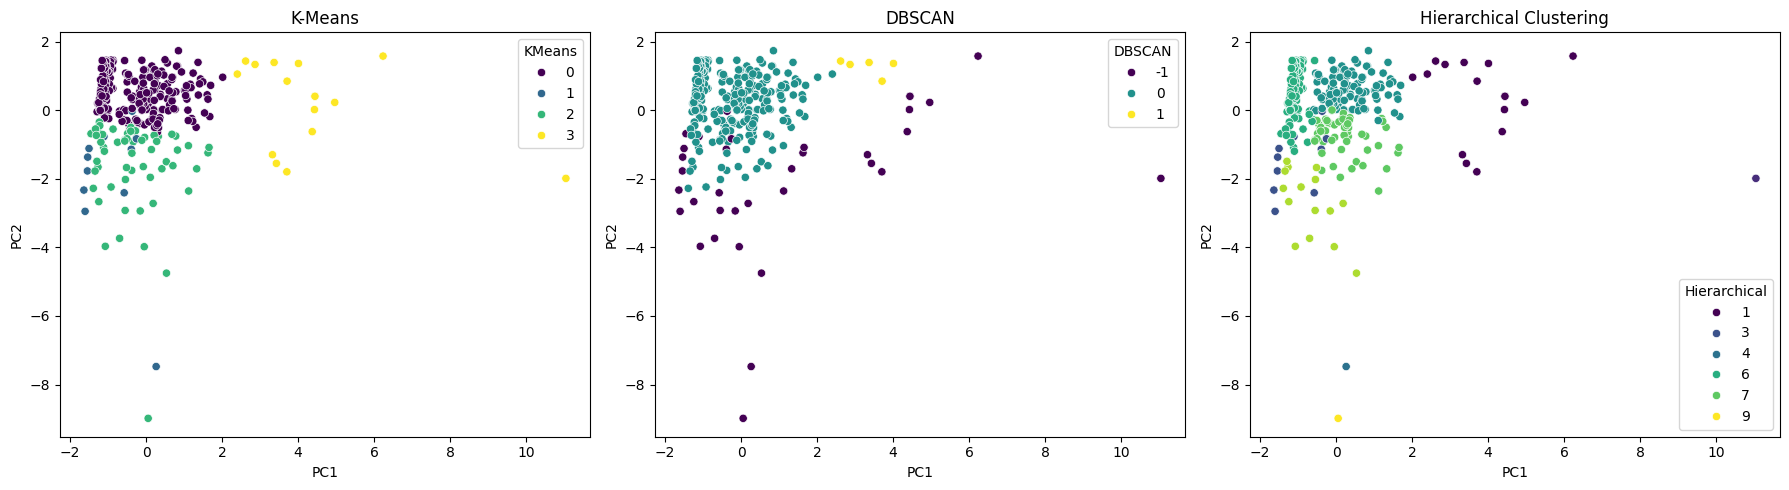

In [60]:
# Apply PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a dataframe for visualization
plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'KMeans': df['KMeans_Cluster'],
    'DBSCAN': df['DBSCAN_Cluster'],
    'Hierarchical': df['Hierarchical_Cluster']
})

# Plot the three clustering results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(
    data=plot_df,
    x='PC1',
    y='PC2',
    hue='KMeans',
    ax=axes[0],
    palette='viridis'
)
axes[0].set_title('K-Means')

sns.scatterplot(
    data=plot_df,
    x='PC1',
    y='PC2',
    hue='DBSCAN',
    ax=axes[1],
    palette='viridis'
)
axes[1].set_title('DBSCAN')

sns.scatterplot(
    data=plot_df,
    x='PC1',
    y='PC2',
    hue='Hierarchical',
    ax=axes[2],
    palette='viridis'
)
axes[2].set_title('Hierarchical Clustering')

plt.tight_layout()
plt.show()

#### Comparison of Clustering Methods

The three clustering methods were applied to the same dataset and compared based on the number of clusters identified.

| Method | Number of Clusters | Noise Points |
|---|---:|---:|
| K-Means | 4 | 0 |
| DBSCAN | 2 | 35 |
| Hierarchical Clustering | 9 | 0 |

### Comparison

- **K-Means** produced 4 clusters and assigns every data point to a cluster.
- **DBSCAN** found 2 dense clusters and identified 35 points as noise.
- **Hierarchical Clustering** produced 9 clusters when the dendrogram was cut at a height of 10.

Overall, DBSCAN was the only method that explicitly identified noise points, while K-Means and Hierarchical Clustering assigned all observations to clusters.

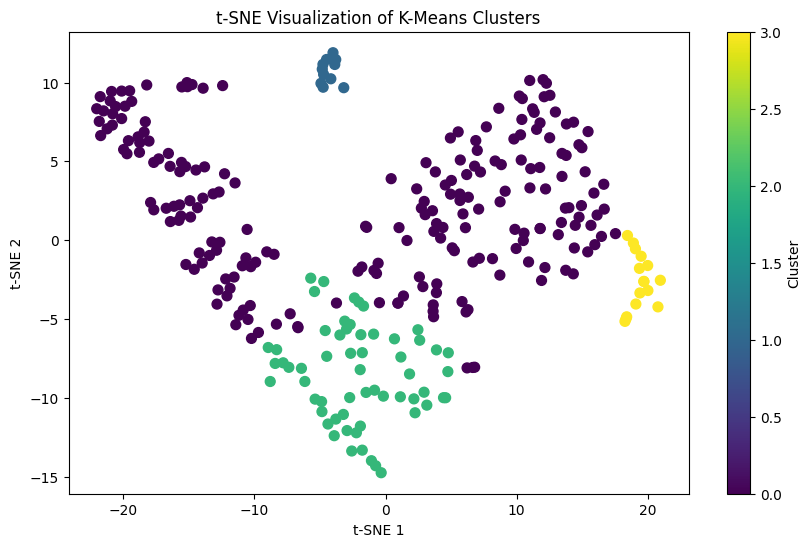

In [61]:
# Apply t-SNE to reduce the data to 2 dimensions
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(X_scaled)

# Plot the 2D representation
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=df['KMeans_Cluster'],
    s=50
)

plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE Visualization of K-Means Clusters')
plt.colorbar(scatter, label='Cluster')

plt.show()

#### t-SNE Visualization

t-SNE was used to reduce the high-dimensional dataset to two dimensions for
visualization. The points are colored according to their K-Means cluster
assignments from Day 1.

The plot shows that some clusters form relatively distinct groups, while
others have some overlap. This suggests that the K-Means clustering captures
some meaningful structure in the data, although the clusters are not completely
separated in the 2D t-SNE representation.

t-SNE is useful for visualizing local patterns and relationships in
high-dimensional data, but the two axes do not have a direct interpretation
like the original features.

/tmp/ipykernel_745/3120960128.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


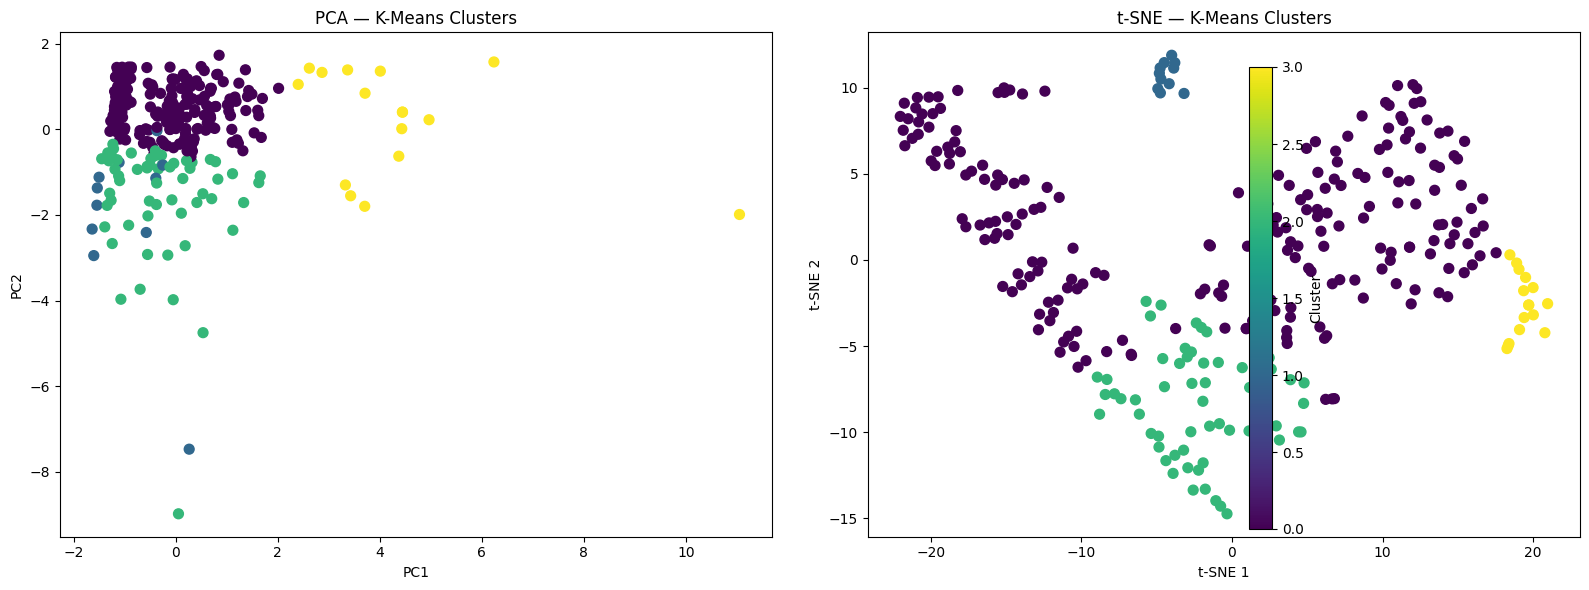

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA
scatter1 = axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['KMeans_Cluster'],
    s=50
)

axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('PCA — K-Means Clusters')

# t-SNE
scatter2 = axes[1].scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=df['KMeans_Cluster'],
    s=50
)

axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].set_title('t-SNE — K-Means Clusters')

# One colorbar
fig.colorbar(scatter2, ax=axes, label='Cluster')

plt.tight_layout()
plt.show()

#### PCA vs. t-SNE Comparison

- **PCA:** Provides a linear reduction of the data and preserves the directions
  with the highest overall variance. It gives a more interpretable representation
  of the main structure in the dataset.

- **t-SNE:** Focuses on preserving local relationships between nearby data points.
  In the t-SNE plot, the K-Means clusters appear more clearly separated in some
  regions, making it useful for visualizing local groupings and patterns.

#### Conclusion

PCA is better for understanding the **overall structure and variance** of the
data, while t-SNE is better for exploring **local patterns and cluster
separation**.

The two methods provide complementary views of the same dataset. t-SNE can make
clusters look more distinct, but its axes do not have a direct interpretation
and the distances between far-away groups should not be over-interpreted.

In [64]:
# Create and fit the Isolation Forest model
iso_forest = IsolationForest(
    contamination='auto',
    random_state=42
)

iso_forest.fit(X_scaled)

# Predict anomalies
anomaly_labels = iso_forest.predict(X_scaled)

# Count anomalies
n_anomalies = (anomaly_labels == -1).sum()

print("Number of anomalies:", n_anomalies)

Number of anomalies: 38


#### Run Isolation Forest

Isolation Forest was applied to the standardized numerical features:

- Year
- Selling_Price
- Present_Price
- Kms_Driven
- Owner

The model flagged **38 points as anomalies**.

**Number of anomalies: 38**

These 38 observations were classified as potential outliers by the Isolation Forest model and will be inspected in the next step to hypothesize why they were flagged.

#### Inspect Two Flagged Points

Isolation Forest flagged **38 observations** as potential anomalies. Two notable observations were inspected to understand why they may have been flagged.

**Flagged Point 1 — Unusually expensive car**

One observation appears far from the main group of observations in the PCA/t-SNE visualization. It is located toward the right side of the plot and is associated with the premium-car group.

**Hypothesis:**  
This point may have been flagged because it has an unusually high `Selling_Price` and/or `Present_Price` compared with most cars in the dataset. The extreme price values make the observation different from the majority of the data.

**Flagged Point 2 — Older/high-mileage car**

Another unusual observation appears among the older/high-mileage group, separated from the main concentration of observations.

**Hypothesis:**  
This point may have been flagged because it has an unusually old `Year` and/or a very high `Kms_Driven`. These extreme values make it substantially different from the typical car in the dataset.

Overall, the two inspected observations appear to be potential anomalies because they have extreme values in important numerical features. However, being flagged as an anomaly does not necessarily mean that the records are incorrect; they may represent legitimate but unusual cars.